<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/geometric-state-navigator/blob/main/notebooks/gsl_multi_agent_bindu_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GSL v6 — Multi-Agent Bindu Demo

This notebook connects:

- multi-agent coalition selection
- 19-petal spiral field geometry
- phase transition tracking
- bindu opening logic

Pipeline:

agents → coalition → field update → phase → bindu check

In [ ]:

import copy
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.random.seed(42)

In [ ]:

# =========================================================
# CONFIG
# =========================================================

N_PETALS = 19
OCTAVES = [9, 6, 3, 1]   # 19 = 9 + 6 + 3 + 1

HEX_KEYS = [
    "red_mass",
    "orange_flow",
    "yellow_struct",
    "green_balance",
    "blue_law",
    "violet_future",
]

COLORS = {
    "red_mass": "#ff4d4d",
    "orange_flow": "#ffb347",
    "yellow_struct": "#ffe44d",
    "green_balance": "#5cff8a",
    "blue_law": "#66b3ff",
    "violet_future": "#d46bff",
}

TARGET = {
    "red_mass": 0.05,
    "orange_flow": 0.30,
    "yellow_struct": 0.32,
    "green_balance": 0.34,
    "blue_law": 0.12,
    "violet_future": 0.12,
}

SPIRAL_TURNS = 1.6
TOTAL_HEIGHT = 2.4
BASE_RADIUS = 1.15
BINDU_HOLD_CYCLES = 2

In [ ]:

# =========================================================
# HELPERS
# =========================================================

def normalize(v):
    s = sum(max(v[k], 0.0) for k in v)
    if s <= 1e-9:
        return {k: 1.0 / len(v) for k in v}
    return {k: max(v[k], 0.0) / s for k in v}

def random_state():
    v = {
        "red_mass": np.random.uniform(0.22, 0.40),
        "orange_flow": np.random.uniform(0.06, 0.16),
        "yellow_struct": np.random.uniform(0.08, 0.18),
        "green_balance": np.random.uniform(0.08, 0.18),
        "blue_law": np.random.uniform(0.06, 0.14),
        "violet_future": np.random.uniform(0.04, 0.12),
    }
    return normalize(v)

def alignment_distance(v):
    g = v["green_balance"]
    y = v["yellow_struct"]
    o = v["orange_flow"]
    return abs(g - y) + abs(y - o) + abs(g - o)

def vec_distance_to_target(v):
    return sum(abs(v[k] - TARGET[k]) for k in HEX_KEYS)

def compute_vitality(v):
    return (
        v["orange_flow"]
        + v["yellow_struct"]
        + v["green_balance"]
        + 0.5 * v["violet_future"]
    )

In [ ]:

# =========================================================
# 19-PETAL FIELD GEOMETRY
# =========================================================

def generate_spiral_positions():
    positions = []
    for i in range(N_PETALS):
        t = i / (N_PETALS - 1)
        theta = 2 * np.pi * SPIRAL_TURNS * t
        radius = BASE_RADIUS * (1.0 - 0.55 * t)
        x = radius * np.cos(theta)
        y = radius * np.sin(theta)
        z = TOTAL_HEIGHT * t
        positions.append((x, y, z))
    return positions

def generate_octave_labels():
    labels = []
    for octave_idx, count in enumerate(OCTAVES):
        labels.extend([octave_idx] * count)
    return labels

def init_bindu_field():
    positions = generate_spiral_positions()
    octaves = generate_octave_labels()

    field = []
    for i in range(N_PETALS):
        field.append({
            "id": i,
            "pos": positions[i],
            "octave": octaves[i],
            "state": random_state()
        })
    return field

In [ ]:

# =========================================================
# GLOBAL FIELD STATE
# =========================================================

def compute_global_state(field):
    avg = {
        k: float(np.mean([node["state"][k] for node in field]))
        for k in HEX_KEYS
    }

    shadow = float(np.mean([node["state"]["red_mass"] for node in field]))
    coherence = 1.0 - min(1.0, alignment_distance(avg) * 2.0)
    target_fit = 1.0 - min(1.0, vec_distance_to_target(avg) * 1.1)
    vitality = compute_vitality(avg)

    if shadow > 0.22:
        phase = "water"
    elif shadow > 0.12:
        phase = "gas"
    elif shadow <= 0.12 and coherence > 0.88 and vitality > 0.74:
        phase = "plasma"
    elif shadow <= 0.08 and coherence > 0.93 and vitality > 0.82 and target_fit > 0.68:
        phase = "crystal"
    else:
        phase = "gas"

    return avg, shadow, coherence, target_fit, vitality, phase

def is_near_bindu_open(avg, shadow, coherence, target_fit, vitality):
    return (
        shadow <= 0.10
        and coherence >= 0.90
        and target_fit >= 0.60
        and vitality >= 0.75
    )

In [ ]:

# =========================================================
# AGENTS
# =========================================================

AGENTS = {
    "planner": {
        "text": "Propose structured plan with fallback paths.",
        "delta": {
            "yellow_struct": 0.10,
            "green_balance": 0.06,
            "orange_flow": 0.02,
            "red_mass": -0.04
        }
    },
    "critic": {
        "text": "Analyze risks and enforce constraints.",
        "delta": {
            "blue_law": 0.10,
            "yellow_struct": 0.05,
            "orange_flow": -0.04,
            "red_mass": -0.02
        }
    },
    "explorer": {
        "text": "Explore alternative strategies.",
        "delta": {
            "orange_flow": 0.12,
            "violet_future": 0.05,
            "yellow_struct": -0.04
        }
    },
    "stabilizer": {
        "text": "Reduce pressure and align system.",
        "delta": {
            "green_balance": 0.10,
            "red_mass": -0.08,
            "orange_flow": 0.03
        }
    }
}

In [ ]:

# =========================================================
# COALITIONS
# =========================================================

from itertools import combinations

def merge_deltas(delta_a, delta_b):
    keys = set(delta_a.keys()) | set(delta_b.keys())
    return {k: delta_a.get(k, 0.0) + delta_b.get(k, 0.0) for k in keys}

def score_from_metrics(shadow, coherence, target_fit, vitality):
    return round(
        coherence * 0.40
        - shadow * 0.30
        + target_fit * 0.20
        + vitality * 0.10,
        3
    )

In [ ]:

# =========================================================
# BRIDGE: DELTA -> 19-PETAL FIELD
# =========================================================

OCTAVE_WEIGHTS = {
    0: {  # outer ring
        "red_mass": 1.00,
        "orange_flow": 1.00,
        "yellow_struct": 0.85,
        "green_balance": 0.80,
        "blue_law": 0.70,
        "violet_future": 0.60,
    },
    1: {
        "red_mass": 0.80,
        "orange_flow": 0.90,
        "yellow_struct": 1.00,
        "green_balance": 1.00,
        "blue_law": 0.90,
        "violet_future": 0.80,
    },
    2: {
        "red_mass": 0.60,
        "orange_flow": 0.70,
        "yellow_struct": 1.00,
        "green_balance": 1.10,
        "blue_law": 1.00,
        "violet_future": 1.00,
    },
    3: {  # inner / bindu-near
        "red_mass": 0.40,
        "orange_flow": 0.50,
        "yellow_struct": 0.90,
        "green_balance": 1.20,
        "blue_law": 1.00,
        "violet_future": 1.20,
    },
}

def apply_delta_to_bindu_field(field, delta):
    new_field = copy.deepcopy(field)

    for node in new_field:
        octave = node["octave"]
        weights = OCTAVE_WEIGHTS[octave]

        v = node["state"].copy()
        for k in HEX_KEYS:
            v[k] += delta.get(k, 0.0) * weights[k]

        node["state"] = normalize(v)

    return new_field

In [ ]:

# =========================================================
# ROUTING + GATING
# =========================================================

def route_mode_from_metrics(shadow, coherence, target_fit, vitality):
    if shadow > 0.12:
        return "stabilize"
    elif target_fit < 0.55:
        return "plan"
    elif coherence < 0.90:
        return "explore"
    else:
        return "balanced"

def reroute_mode(mode):
    fallback = {
        "stabilize": "plan",
        "plan": "explore",
        "explore": "balanced",
        "balanced": "stabilize"
    }
    return fallback.get(mode, "balanced")

def gate_decision(shadow, coherence, target_fit, vitality):
    if shadow <= 0.08 and coherence >= 0.90:
        return "COMMIT"
    elif shadow <= 0.12 and coherence >= 0.84:
        return "SOFT_COMMIT"
    elif vitality >= 0.70:
        return "REROUTE"
    else:
        return "REJECT"

def evaluate_bindu_coalitions(field, mode):
    allowed = {
        "stabilize": [("planner", "stabilizer"), ("critic", "stabilizer")],
        "plan": [("planner", "critic"), ("planner", "stabilizer")],
        "explore": [("planner", "explorer"), ("critic", "explorer")],
        "balanced": [
            ("planner", "explorer"),
            ("planner", "stabilizer"),
            ("planner", "critic")
        ]
    }

    results = {}

    for a, b in combinations(AGENTS.keys(), 2):
        if (a, b) not in allowed.get(mode, []) and (b, a) not in allowed.get(mode, []):
            continue

        coalition_name = f"{a}+{b}"
        merged_delta = merge_deltas(AGENTS[a]["delta"], AGENTS[b]["delta"])

        new_field = apply_delta_to_bindu_field(field, merged_delta)
        avg, shadow, coherence, target_fit, vitality, phase = compute_global_state(new_field)

        results[coalition_name] = {
            "agents": (a, b),
            "delta": merged_delta,
            "field": new_field,
            "avg": avg,
            "shadow": shadow,
            "coherence": coherence,
            "target_fit": target_fit,
            "vitality": vitality,
            "phase": phase,
            "score": score_from_metrics(shadow, coherence, target_fit, vitality)
        }

    return results

def select_best_coalition(results):
    return max(results.items(), key=lambda x: x[1]["score"])

In [ ]:

# =========================================================
# RENDER
# =========================================================

def dominant_color(state):
    top_key = max(state, key=state.get)
    return COLORS[top_key], top_key

def plot_bindu_field(field, title="Bindu Field"):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    xs, ys, zs = [], [], []
    cs = []
    sizes = []

    for node in field:
        x, y, z = node["pos"]
        color, _ = dominant_color(node["state"])
        intensity = max(node["state"].values())

        xs.append(x)
        ys.append(y)
        zs.append(z)
        cs.append(color)
        sizes.append(80 + 220 * intensity)

    ax.scatter(xs, ys, zs, c=cs, s=sizes, alpha=0.9)

    # connect local spiral order
    for i in range(len(field) - 1):
        x1, y1, z1 = field[i]["pos"]
        x2, y2, z2 = field[i + 1]["pos"]
        ax.plot([x1, x2], [y1, y2], [z1, z2], alpha=0.25)

    # bindu point
    ax.scatter([0], [0], [TOTAL_HEIGHT + 0.15], c="white", s=180, marker="*")

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.show()

=== INITIAL GLOBAL STATE ===
{'shadow': 0.342, 'coherence': 0.903, 'target_fit': 0.082, 'vitality': 0.493, 'phase': 'water', 'bindu_near': False}


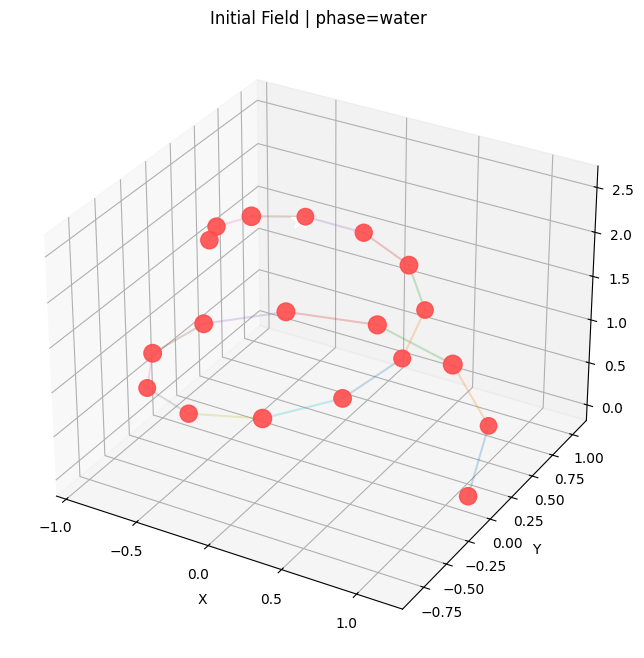

In [ ]:

# =========================================================
# INITIAL STATE
# =========================================================

field = init_bindu_field()

avg, shadow, coherence, target_fit, vitality, phase = compute_global_state(field)

print("=== INITIAL GLOBAL STATE ===")
print({
    "shadow": round(shadow, 3),
    "coherence": round(coherence, 3),
    "target_fit": round(target_fit, 3),
    "vitality": round(vitality, 3),
    "phase": phase,
    "bindu_near": is_near_bindu_open(avg, shadow, coherence, target_fit, vitality)
})

plot_bindu_field(field, title=f"Initial Field | phase={phase}")

In [ ]:

# =========================================================
# EPISODE LOOP
# =========================================================

def run_bindu_agent_episode(initial_field, max_steps=8):
    current_field = copy.deepcopy(initial_field)
    memory = []
    trace = []
    bindu_hold = 0

    for step in range(max_steps):
        avg, shadow, coherence, target_fit, vitality, phase = compute_global_state(current_field)

        mode = route_mode_from_metrics(shadow, coherence, target_fit, vitality)
        coalition_results = evaluate_bindu_coalitions(current_field, mode)
        best_name, best_data = select_best_coalition(coalition_results)

        decision = gate_decision(
            best_data["shadow"],
            best_data["coherence"],
            best_data["target_fit"],
            best_data["vitality"]
        )

        trace.append({
            "step": step,
            "mode": mode,
            "coalition": best_name,
            "decision": decision,
            "shadow": round(best_data["shadow"], 3),
            "coherence": round(best_data["coherence"], 3),
            "target_fit": round(best_data["target_fit"], 3),
            "vitality": round(best_data["vitality"], 3),
            "phase": best_data["phase"]
        })

        if decision in ["COMMIT", "SOFT_COMMIT"]:
            current_field = copy.deepcopy(best_data["field"])
            memory.append(trace[-1])

        elif decision == "REROUTE":
            fallback = reroute_mode(mode)
            fallback_results = evaluate_bindu_coalitions(current_field, fallback)
            rer_name, rer_data = select_best_coalition(fallback_results)

            rer_decision = gate_decision(
                rer_data["shadow"],
                rer_data["coherence"],
                rer_data["target_fit"],
                rer_data["vitality"]
            )

            trace.append({
                "step": step,
                "mode": fallback,
                "coalition": rer_name,
                "decision": f"FALLBACK_{rer_decision}",
                "shadow": round(rer_data["shadow"], 3),
                "coherence": round(rer_data["coherence"], 3),
                "target_fit": round(rer_data["target_fit"], 3),
                "vitality": round(rer_data["vitality"], 3),
                "phase": rer_data["phase"]
            })

            if rer_decision in ["COMMIT", "SOFT_COMMIT"]:
                current_field = copy.deepcopy(rer_data["field"])
                memory.append(trace[-1])

        avg2, shadow2, coherence2, target_fit2, vitality2, phase2 = compute_global_state(current_field)
        near = is_near_bindu_open(avg2, shadow2, coherence2, target_fit2, vitality2)

        if near:
            bindu_hold += 1
        else:
            bindu_hold = 0

        if bindu_hold >= BINDU_HOLD_CYCLES:
            return current_field, memory, trace, True

    return current_field, memory, trace, False


final_field, memory_log, episode_trace, bindu_opened = run_bindu_agent_episode(field, max_steps=8)

In [ ]:

print("=== BINDU AGENT EPISODE TRACE ===\n")

for row in episode_trace:
    print(
        f"step={row['step']} | "
        f"mode={row['mode']:10s} | "
        f"coalition={row['coalition']:20s} | "
        f"decision={row['decision']:15s} | "
        f"phase={row['phase']:8s} | "
        f"shadow={row['shadow']:.3f} | "
        f"coh={row['coherence']:.3f} | "
        f"fit={row['target_fit']:.3f} | "
        f"vit={row['vitality']:.3f}"
    )

print("\n=== MEMORY LOG ===\n")
for row in memory_log:
    print(row)

avg_f, shadow_f, coherence_f, target_fit_f, vitality_f, phase_f = compute_global_state(final_field)

print("\n=== FINAL FIELD ===")
print({
    "shadow": round(shadow_f, 3),
    "coherence": round(coherence_f, 3),
    "target_fit": round(target_fit_f, 3),
    "vitality": round(vitality_f, 3),
    "phase": phase_f,
    "bindu_opened": bindu_opened
})

=== BINDU AGENT EPISODE TRACE ===

step=0 | mode=stabilize  | coalition=planner+stabilizer   | decision=REJECT          | phase=gas      | shadow=0.203 | coh=0.569 | fit=0.388 | vit=0.658
step=1 | mode=stabilize  | coalition=planner+stabilizer   | decision=REJECT          | phase=gas      | shadow=0.203 | coh=0.569 | fit=0.388 | vit=0.658
step=2 | mode=stabilize  | coalition=planner+stabilizer   | decision=REJECT          | phase=gas      | shadow=0.203 | coh=0.569 | fit=0.388 | vit=0.658
step=3 | mode=stabilize  | coalition=planner+stabilizer   | decision=REJECT          | phase=gas      | shadow=0.203 | coh=0.569 | fit=0.388 | vit=0.658
step=4 | mode=stabilize  | coalition=planner+stabilizer   | decision=REJECT          | phase=gas      | shadow=0.203 | coh=0.569 | fit=0.388 | vit=0.658
step=5 | mode=stabilize  | coalition=planner+stabilizer   | decision=REJECT          | phase=gas      | shadow=0.203 | coh=0.569 | fit=0.388 | vit=0.658
step=6 | mode=stabilize  | coalition=planner+st

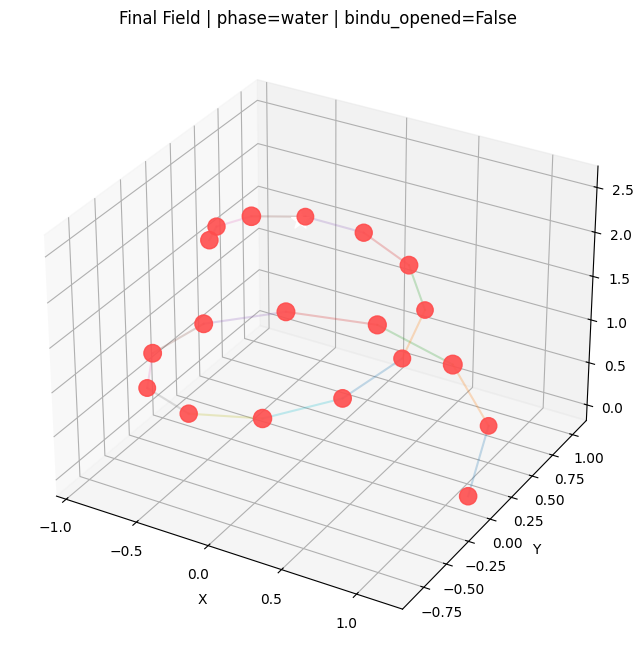

In [ ]:

plot_bindu_field(
    final_field,
    title=f"Final Field | phase={phase_f} | bindu_opened={bindu_opened}"
)

In [ ]:

steps = list(range(len(memory_log)))
shadow_vals = [row["shadow"] for row in memory_log]
coh_vals = [row["coherence"] for row in memory_log]
fit_vals = [row["target_fit"] for row in memory_log]
vit_vals = [row["vitality"] for row in memory_log]

if len(steps) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(steps, shadow_vals, marker="o", label="shadow")
    plt.plot(steps, coh_vals, marker="o", label="coherence")
    plt.plot(steps, fit_vals, marker="o", label="target_fit")
    plt.plot(steps, vit_vals, marker="o", label="vitality")
    plt.title("Bindu Agent Memory Metrics")
    plt.xlabel("memory step")
    plt.ylabel("value")
    plt.legend()
    plt.show()
else:
    print("No committed memory states recorded.")

No committed memory states recorded.
